# Lensing-Cls constraining power (blinded)

Investigate the constraining power of the lensing angular power spectra (Cls) and compare it, **by contour size only**, with Fig. 14 of Jeffrey, Whiteway, Gatti et al. 2024 (DES Y3 SBI wCDM, [arXiv:2403.02314](https://arxiv.org/pdf/2403.02314)).

The analysis is still **blinded**: every posterior is shifted so its MAP sits at the fiducial cosmology (`- find_MAP(chain) + fiducial`), which hides the absolute position while preserving the contour size/shape exactly. This is the same convention as `deep_lss_paper/paper_2/pre-unblinding/6_shifted_posterior.ipynb`, reusing the shared helpers in `msi.utils` (`plotting.find_MAP`, `parameters.get_fiducials`, `diagnostics.FoM_from_chain_nd`, `prior.assess_prior_boundary`) and `trianglechain.TriangleChain`.

**Model variants compared** (all from the same trained lensing-Cls flow, `lmax_1024`, scale cut `configs/scales/lmax_1024.yaml`, `l in [30, 1024]`):
- `wCDM` — full model (`chain_DESy3.npy`).
- `w0>-1` — non-phantom half, w0 still sampled (`chain_DESy3_w0gt-1.npy`).
- `w0>-1 & NLA` — the DES-Y3-like target model: w0>-1 **and** bta=0 so the intrinsic-alignment model reduces from delta-NLA/TATT to standard NLA (`chain_DESy3_w0gt-1_nla.npy`). `bta` is dropped from the sampled space, so this chain has parameters `[Om, s8, w0, Aia, n_Aia]` (no `bta`).

FoM is `det(cov)^(-1/2)` (shift-invariant), so it is safe to report and tabulate under blinding.

> **Kernel:** run with the PyTorch environment (`uenv pytorch/v2.9.1:v2` + `~/dlss/torch_env`) — loading `msi.flow_conductor` needs torch. Chain **loading + plotting** cells are light and run anywhere; only the optional generation cell needs a GPU.

**Optional sweep comparison.** Beyond the single `MODEL_NAME` run, the last section can compare a whole set of runs (e.g. the bench_m1 sweep, `m1_*`) — analogous to [`y3-deep-lss/notebooks/fom_parameter_space.ipynb`](../../../y3-deep-lss/notebooks/fom_parameter_space.ipynb). Set `COMPARE_GLOBS` below; leave it `None` to analyse only `MODEL_NAME`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files as msfm_files, parameters, prior
from msi.utils import plotting, diagnostics

# -------------------------------------------------------------------------------------------------
# Config — point RUN_DIR at any cls/lensing run; future cls_training.sh runs just change MODEL_NAME.
# -------------------------------------------------------------------------------------------------
RUN_BASE   = "/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing"
MODEL_NAME = "m1_default"
FLOW_NAME  = "ensemble_flow"   # v33+/v8 inference runs save under ensemble_flow_<steps>
STEPS      = 1_000_000
MSFM_CONFIG = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model/configs/v16/rot_in_place.yaml"

# training-order params of this flow (from the runs config / configs.yaml)
PARAMS     = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
PARAMS_NLA = [p for p in PARAMS if p != "bta"]   # bta dropped in the NLA (bta=0) chain

RUN_DIR = os.path.join(RUN_BASE, MODEL_NAME)
FDIR    = os.path.join(RUN_DIR, f"{FLOW_NAME}_{STEPS}")
msfm_conf = msfm_files.load_config(MSFM_CONFIG)
print("flow dir:", FDIR)
print("exists:", os.path.isdir(FDIR))

# -------------------------------------------------------------------------------------------------
# Optional multi-run sweep comparison (last section). Point COMPARE_GLOBS at run globs under
# RUN_BASE (e.g. the bench_m1 sweep); set to None/[] to skip and analyse only MODEL_NAME above.
# -------------------------------------------------------------------------------------------------
COMPARE_GLOBS     = ["m1_*"]        # e.g. ["m1_*"]; None -> single-run only
COMPARE_HIGHLIGHT = MODEL_NAME       # reference run, highlighted in plots (or None)
EVAL_STEP         = STEPS            # pin every run to {FLOW_NAME}_<step>; None -> latest each

/users/athomsen/dlss/torch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


flow dir: /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing/m1_default/ensemble_flow_1000000
exists: True


In [2]:
# -------------------------------------------------------------------------------------------------
# Loading + blinded-shift + FoM helpers (mirror msi.utils.shifted_posterior, but with an explicit
# per-chain parameter list so the reduced NLA chain, which has no `bta` column, loads correctly).
# -------------------------------------------------------------------------------------------------
def load_raw(obs_label, fdir=FDIR):
    chain = np.load(os.path.join(fdir, f"chain_{obs_label}.npy"))
    log_probs = np.load(os.path.join(fdir, f"log_probs_{obs_label}.npy"))
    return chain, log_probs

def slice_chain(chain, chain_params, test_params):
    """Slice a raw chain to `test_params`; derive S8 = sigma8 * sqrt(Om/0.3) on the fly."""
    cols = []
    for p in test_params:
        if p == "S8":
            om = chain[:, chain_params.index("Om")]
            s8 = chain[:, chain_params.index("s8")]
            cols.append(plotting.sigma8_to_S8(sigma8=s8, Om=om))
        else:
            cols.append(chain[:, chain_params.index(p)])
    return np.stack(cols, axis=1)

def shifted(chain, log_probs, chain_params, test_params, guard=True):
    """Blinded chain: sliced to test_params and shifted so its MAP sits at the fiducial cosmology."""
    sl = slice_chain(chain, chain_params, test_params)
    if guard and prior.assess_prior_boundary(sl, params=test_params, conf=msfm_conf, blinded=True):
        print(f"WARNING: {test_params} presses a prior boundary — MAP shift may be unreliable")
    sl = sl - plotting.find_MAP(sl, log_probs, test_params, test_params)
    sl = sl + parameters.get_fiducials(test_params, msfm_conf)
    return sl

def fom(chain, chain_params, param_set):
    """N-d figure of merit det(cov)^(-1/2) over param_set (covariance-based -> shift-invariant)."""
    return diagnostics.FoM_from_chain_nd(slice_chain(chain, chain_params, param_set), param_set, param_set)

In [3]:
# -------------------------------------------------------------------------------------------------
# Load the DES chains. wCDM + w0>-1 are full-dimensional; the w0>-1 & NLA chain has bta dropped.
# -------------------------------------------------------------------------------------------------
CHAINS = {}  # label -> (chain, log_probs, chain_params)

def try_load(label, obs_label, chain_params):
    path = os.path.join(FDIR, f"chain_{obs_label}.npy")
    if not os.path.exists(path):
        print(f"[missing] {label}: {path}")
        return
    chain, lp = load_raw(obs_label)
    CHAINS[label] = (chain, lp, chain_params)
    print(f"[loaded ] {label:14s} shape={chain.shape} params={chain_params}")

try_load("wCDM",        "DESy3",            PARAMS)
try_load("w0>-1",       "DESy3_w0gt-1",     PARAMS)
try_load("w0>-1 & NLA", "DESy3_w0gt-1_nla", PARAMS_NLA)

[loaded ] wCDM           shape=(1024000, 6) params=['Om', 's8', 'w0', 'Aia', 'n_Aia', 'bta']
[loaded ] w0>-1          shape=(1024000, 6) params=['Om', 's8', 'w0', 'Aia', 'n_Aia', 'bta']
[loaded ] w0>-1 & NLA    shape=(1024000, 5) params=['Om', 's8', 'w0', 'Aia', 'n_Aia']


## (Optional) backfill the `w0>-1 & NLA` chain for this existing run

New `cls_training.sh` runs produce `chain_DESy3_w0gt-1_nla.npy` **automatically** (the combined w0>-1 & NLA DES variant was added to `msi/utils/observations.py`, emitted for any probe that has `bta` among its params). For the pre-existing `lmax_1024` run there are two ways to backfill it:

**A. Re-run the inference stage (recommended, reproducible).** Loads the trained flow and regenerates every chain, now including the combined variant:
```bash
srun -N1 --ntasks-per-node=1 --gpus-per-task=1 --cpus-per-task=72 --mem=110G \
    --uenv=pytorch/v2.9.1:v2 --view=default \
    bash -c "source ~/dlss/torch_env/bin/activate && \
      python /users/athomsen/dlss/repos/multiprobe-simulation-inference/msi/apps/run_inference.py \
        --out_dir='/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing' \
        --model_name='lmax_1024' \
        --flow_config='/users/athomsen/dlss/repos/multiprobe-simulation-inference/configs/flow/maf.yaml' \
        --n_flows=4 --load_flow --include_des"
```

**B. Generate only this one chain in-notebook** (cheaper; needs a GPU). Set `GENERATE = True` and run the cell below.

In [4]:
GENERATE = False  # set True on a GPU node to backfill just chain_DESy3_w0gt-1_nla.npy

if GENERATE and "w0>-1 & NLA" not in CHAINS:
    from msi.flow_conductor.likelihood_flow import LikelihoodFlowEnsemble
    from msi.utils import flow as flow_utils, observations

    pred_dir, pred_file, n_steps = flow_utils.resolve_pred_file(RUN_BASE, MODEL_NAME, STEPS)
    grid_preds, grid_cosmos, obs_pred_dict, obs_cosmo_dict, i_signal, i_sobol = flow_utils.load_grid_summaries(pred_file)

    flow = LikelihoodFlowEnsemble.from_checkpoint(out_dir=pred_dir, suffix=f"_{STEPS}")
    x_des = np.atleast_2d(obs_pred_dict["DESy3"])

    chains_wn, lp_wn = flow.sample_posterior_batched(
        x_des, w0_prior=observations.W0_GT_M1_PRIOR, nla=True, method="ensemble"
    )
    np.save(os.path.join(FDIR, "chain_DESy3_w0gt-1_nla.npy"), chains_wn[0])
    np.save(os.path.join(FDIR, "log_probs_DESy3_w0gt-1_nla.npy"), lp_wn[0])
    print("saved w0>-1 & NLA chain", chains_wn[0].shape)

    try_load("w0>-1 & NLA", "DESy3_w0gt-1_nla", PARAMS_NLA)

In [5]:
# -------------------------------------------------------------------------------------------------
# Figure of merit table (shift-invariant, blinding-safe). Higher = tighter = more constraining.
# -------------------------------------------------------------------------------------------------
import pandas as pd

FOM_SETS = [["Om", "s8"], ["Om", "S8"], ["Om", "s8", "w0"], ["Om", "S8", "w0"]]

rows = []
for label, (chain, lp, cp) in CHAINS.items():
    row = {"variant": label}
    for s in FOM_SETS:
        row["FoM(" + ",".join(s) + ")"] = int(round(fom(chain, cp, s)))
    rows.append(row)

fom_table = pd.DataFrame(rows).set_index("variant")
fom_table

,"FoM(Om,s8)","FoM(Om,S8)","FoM(Om,s8,w0)","FoM(Om,S8,w0)"
variant,,,,
wCDM,272,335,1330,1914
w0>-1,317,392,2104,2855
w0>-1 & NLA,315,391,2037,2687


26-07-10 13:20:00     prior.py INF   Assessing prior boundaries in ['Om', 's8'] for chain in ['Om', 's8'] 
26-07-10 13:20:00     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 13:20:01     prior.py INF   Assessing prior boundaries in ['Om', 's8'] for chain in ['Om', 's8'] 
26-07-10 13:20:01     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 13:20:01     prior.py INF   Assessing prior boundaries in ['Om', 's8'] for chain in ['Om', 's8'] 
26-07-10 13:20:01     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 13:20:02     prior.py INF   Assessing prior boundaries in ['Om', 's8', 'w0'] for chain in ['Om', 's8', 'w0'] 
26-07-10 13:20:02     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 13:20:02     prior.py INF   Assessing prior boundaries in ['Om', 's8', 'w0'] for chain in ['Om', 's8', 'w0'] 
26-07-10 13:20:02     prior.py INF   Prior boundary assessment (b

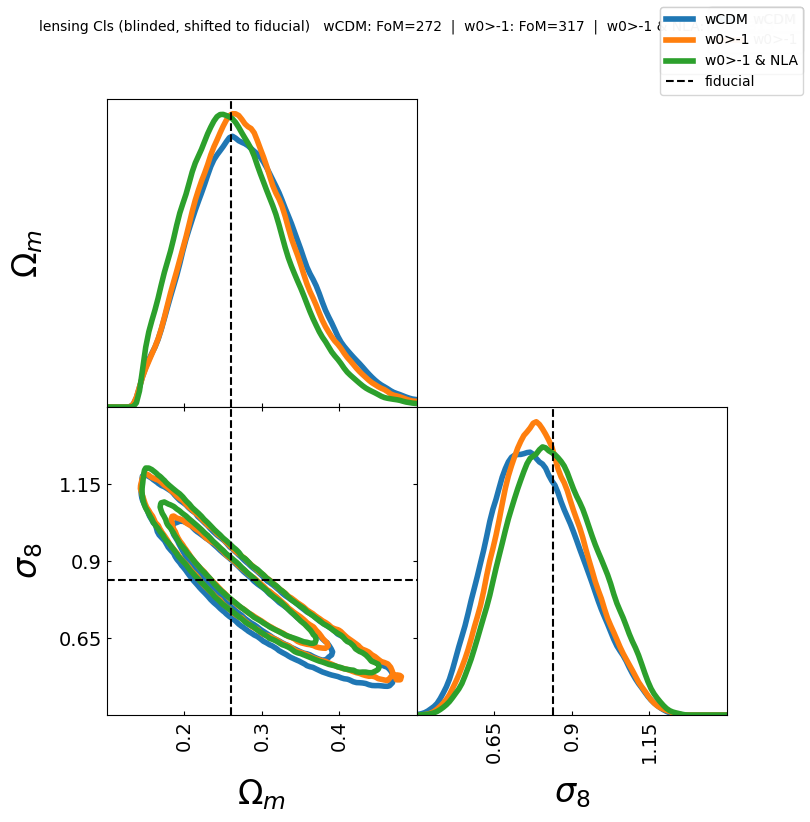

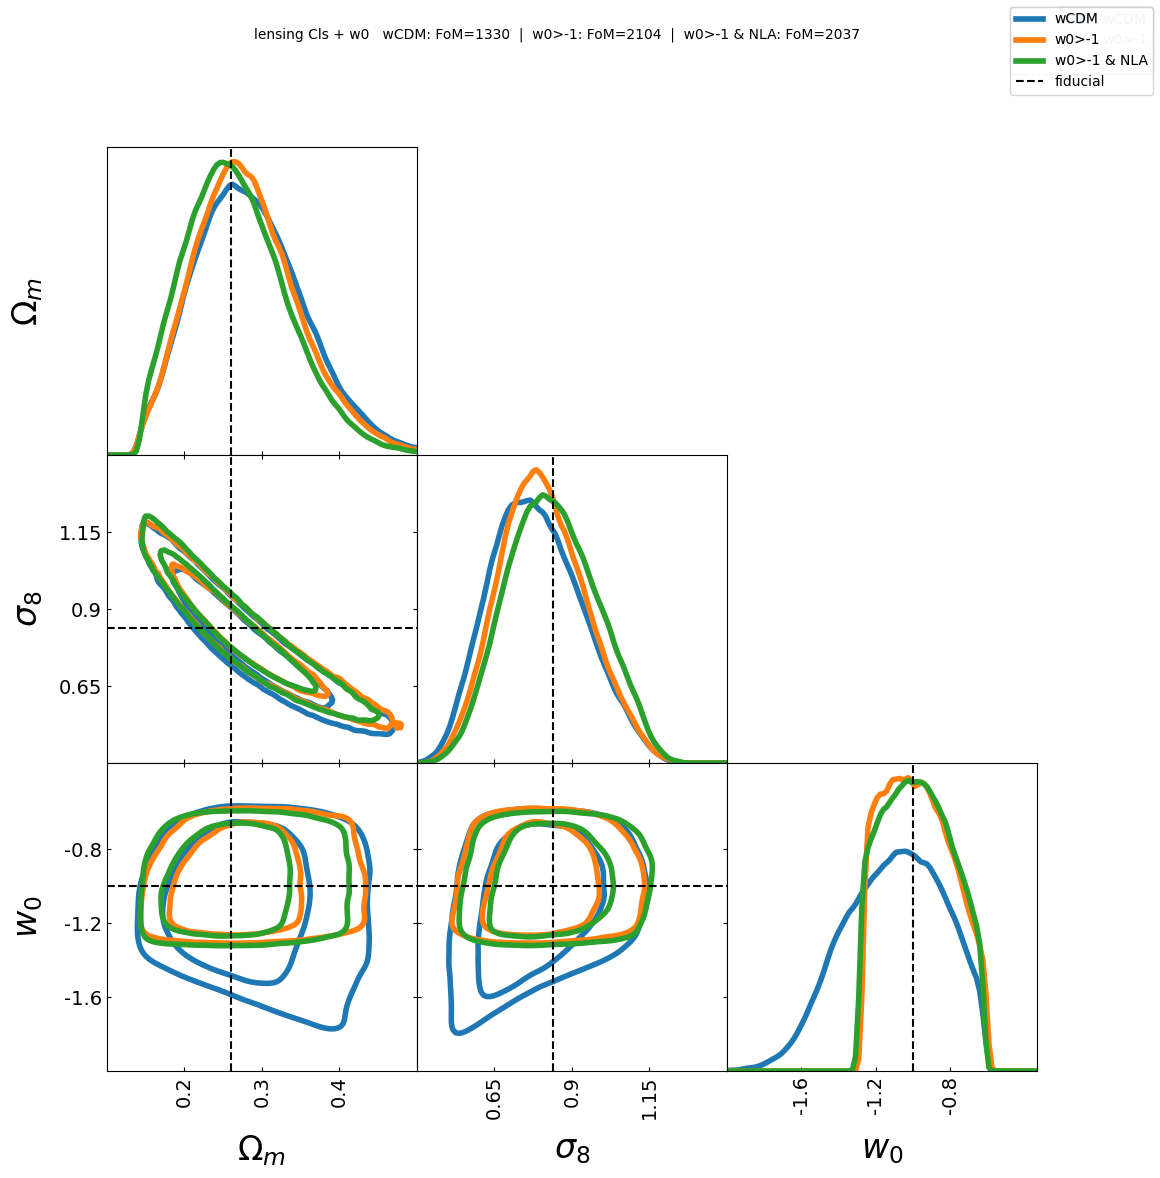

In [6]:
# -------------------------------------------------------------------------------------------------
# Blinded contour overlay of the model variants (all shifted to the fiducial). Compare SIZE only.
# Shown in both sigma8 (natively sampled) and S8 = sigma8*sqrt(Om/0.3), the lensing-standard
# combination plotted in Fig. 14 of Jeffrey+2024 -> use the S8 panels for the direct visual match.
# -------------------------------------------------------------------------------------------------
from trianglechain import TriangleChain

def compare(test_params, title=""):
    ref = parameters.get_fiducials(test_params, msfm_conf)
    # S8 is derived; its config "prior" is the full envelope [0.23, 1.81], far wider than the
    # posterior, so we drop it from `ranges` and let TriangleChain auto-scale that axis (keeps the
    # blinded contour readable). Sampled params keep their prior-interval axis ranges.
    ranges = {p: parameters.get_prior_intervals([p], msfm_conf)[0] for p in test_params if p != "S8"}
    tri = TriangleChain(
        names=test_params,
        labels=[plotting.param_label_dict[p] for p in test_params],
        ranges=ranges,
        fill=False, show_legend=True, axlines_kwargs={"linestyle": "--"}, progress_bar=False,
    )
    parts = []
    for label, (chain, lp, cp) in CHAINS.items():
        tri.contour_cl(shifted(chain, lp, cp, test_params), names=test_params, label=label)
        if len(test_params) >= 2:
            f = int(round(fom(chain, cp, test_params)))
            parts.append(f"{label}: FoM={f}")
    tri.axlines(ref[np.newaxis], names=test_params, color="k", label="fiducial")
    tri.fig.suptitle((title + "   " + "  |  ".join(parts)).strip(), fontsize=10)
    return tri

# sigma8 (natively sampled)
compare(["Om", "s8"], title="lensing Cls (blinded, shifted to fiducial)")
compare(["Om", "s8", "w0"], title="lensing Cls + w0")
# S8 -- the plane shown in Fig. 14 of Jeffrey+2024, for direct visual comparison of contour size
compare(["Om", "S8"], title="lensing Cls in the Om-S8 plane (cf. Fig. 14)")
compare(["Om", "S8", "w0"], title="lensing Cls: Om-S8-w0 (cf. Fig. 14)")
plt.show()

## Constraining power across parameter space (held-out mocks)

A single (blinded) DES contour is one draw; the cleaner constraining-power metric — and the closest analogue to a "figure of merit across parameter space" — is the FoM averaged over the held-out mock cosmologies in `mcmc_samples.h5` (full wCDM posteriors, this mirrors `y3-deep-lss/notebooks/fom_parameter_space.ipynb`). This needs no shifting (the mock truths are known and FoM is covariance-based).

held-out mocks: 1000
median FoM(Om,s8) = 511   median FoM(Om,S8) = 544


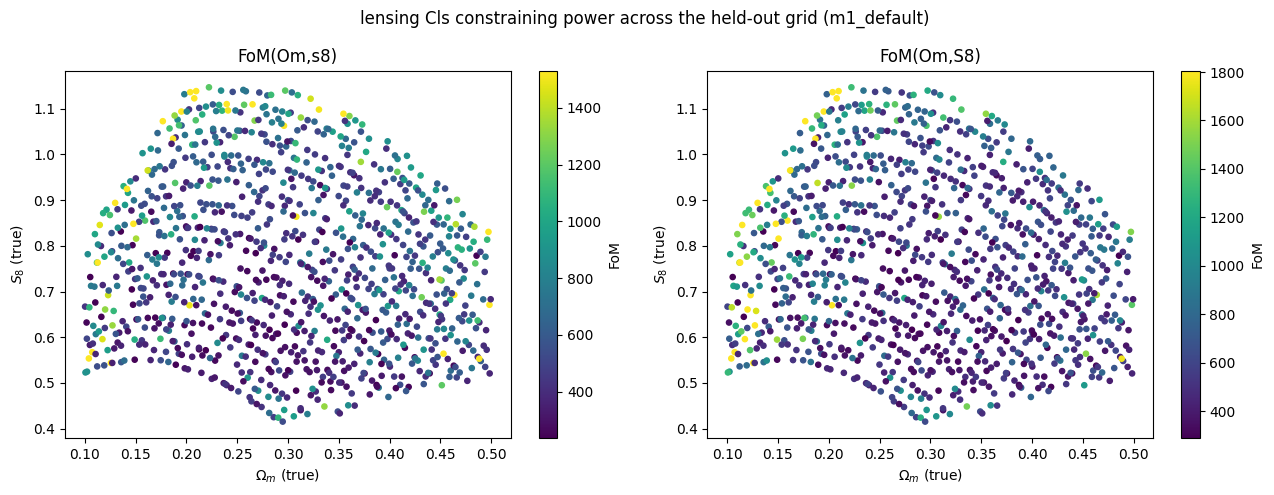

In [7]:
import h5py

def s8_of(sigma8, Om):
    return sigma8 * np.sqrt(Om / 0.3)

def per_obs_fom_2d(samples, i1, i2):
    """2D det(cov)^(-1/2) per observation. samples: (n_samp, n_obs). Vectorized over observations."""
    a, b = samples[0], samples[1]
    am = a - a.mean(0); bm = b - b.mean(0)
    caa = (am * am).mean(0); cbb = (bm * bm).mean(0); cab = (am * bm).mean(0)
    return 1.0 / np.sqrt(np.clip(caa * cbb - cab ** 2, 1e-30, None))

mcmc_file = os.path.join(FDIR, "mcmc_samples.h5")
if os.path.exists(mcmc_file):
    with h5py.File(mcmc_file, "r") as f:
        theta_true = f["theta_true"][:]              # (n_obs, n_params)
        theta_sample = f["theta_sample"][:]          # (n_samp, n_obs, n_params)
    i_om, i_s8 = PARAMS.index("Om"), PARAMS.index("s8")
    om_s = theta_sample[:, :, i_om]
    s8_s = theta_sample[:, :, i_s8]
    S8_s = s8_of(s8_s, om_s)

    fom_om_s8 = per_obs_fom_2d(np.stack([om_s, s8_s]), 0, 1)
    fom_om_S8 = per_obs_fom_2d(np.stack([om_s, S8_s]), 0, 1)
    print(f"held-out mocks: {theta_true.shape[0]}")
    print(f"median FoM(Om,s8) = {np.median(fom_om_s8):.0f}   median FoM(Om,S8) = {np.median(fom_om_S8):.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    om_true = theta_true[:, i_om]
    S8_true = s8_of(theta_true[:, i_s8], om_true)
    for ax, f_val, name in zip(axes, [fom_om_s8, fom_om_S8], ["FoM(Om,s8)", "FoM(Om,S8)"]):
        vmin, vmax = np.percentile(f_val, [2, 98])
        sc = ax.scatter(om_true, S8_true, c=f_val, s=14, cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set(xlabel=r"$\Omega_m$ (true)", ylabel=r"$S_8$ (true)", title=name)
        fig.colorbar(sc, ax=ax, label="FoM")
    fig.suptitle(f"lensing Cls constraining power across the held-out grid ({MODEL_NAME})")
    plt.tight_layout(); plt.show()
else:
    print(f"[missing] {mcmc_file} — run inference with --sample_posterior to produce it")

## Comparison with Fig. 14 (qualitative)

Fig. 14 of [arXiv:2403.02314](https://arxiv.org/pdf/2403.02314) shows the DES Y3 constraining power from the (SBI) weak-lensing power spectra. As chosen, no external chain is overlaid here — read off the FoM numbers and contour sizes above and compare **by eye** to the published figure. The `w0>-1 & NLA` variant is the closest match to the model space of that analysis (NLA intrinsic alignments, non-phantom dark energy).

Under blinding only the contour **size / FoM** is meaningful; the absolute positions have all been shifted to the fiducial, so do not read anything into where the contours sit.

To add a quantitative external overlay later, `msi/utils/chains.py` already provides `load_des_y3_key_project_chain(...)` and `load_des_y3_harmonic_chain(...)` (both TATT->NLA-restricted when NLA params are requested), and `load_and_shift_des_chain(...)` applies the same MAP->fiducial blinding shift used above.

The blinded contour overlays above now include **S8** panels (`Om`-`S8` and `Om`-`S8`-`w0`) alongside the natively sampled `sigma8`, since Fig. 14 is drawn in the `S8` plane — compare the `S8` contour **sizes** (and the FoM annotations) directly.

## Comparison with published DES Y3 constraints

Three published DES Y3 analyses give useful reference points. **All of them define the Figure of
Merit exactly as this notebook does** — `FoM = det(Cov)^(-1/2)` over a parameter subspace (eq. 17 of
Gatti+2024, which `diagnostics.FoM_from_chain_nd` cites) — so the numbers are directly comparable,
subject to the caveats at the end of this section.

| ref | paper | what | comparison |
|---|---|---|---|
| **J24** | Jeffrey, Whiteway, Gatti+ 2024, [2403.02314](https://arxiv.org/pdf/2403.02314), **Table 2** | wCDM 68% intervals for power spectrum / peaks / map-level `Cl x CNN`; **no FoM quoted** | its *power-spectrum* row is the **direct Cls-only analogue** → compare **error-bar sizes** |
| **W26** | Williamson, Makinen+ 2026, [2606.11309](https://arxiv.org/pdf/2606.11309), **Table 3** | wCDM (prior `-1 < w0 < -1/3`) with FoM; `Cl x CNN`, hybrid, and 2pt | `Cl x CNN` FoM is the requested check (map-level, **not** Cls-only → a loose upper reference); its w0 prior matches this notebook's **`w0>-1`** cut |
| **G24** | Gatti+ 2024, [2405.10881](https://arxiv.org/pdf/2405.10881), **Tables IV & III** | 2nd-moments constraints, wCDM (`w0>-1`, NLA) and LCDM, with `FoM(sigma8, Om)` | different statistic → **sanity check**; wCDM row (`w0>-1`, NLA) maps to the **`w0>-1 & NLA`** chain |

Values below are transcribed verbatim from the papers.

In [ ]:
# Published reference values (verbatim). Error bars are 68% credible intervals (value, +err, -err);
# w0 as a one-sided string. FoM keys use the same "p1,p2[,p3]" convention as this notebook. Note the
# plane: W26 FoMs are in the S8 plane, G24 FoMs are in the sigma8 plane -- see the caveats cell.
LIT = {
    # --- J24 (2403.02314) Table 2: wCDM, NO FoM. "power spectrum" row = the Cls-only analogue. ---
    "J24 power spectrum (Cl)": dict(src="2403.02314 T2", stat="lensing Cl (2pt)", model="wCDM",
                                    Om=(0.352, 0.035, 0.053), S8=(0.807, 0.027, 0.025), w0="<-0.661"),
    "J24 peaks":               dict(src="2403.02314 T2", stat="peaks", model="wCDM",
                                    Om=(0.340, 0.030, 0.042), S8=(0.807, 0.023, 0.023), w0="<-0.740"),
    "J24 map-level Cl x CNN":  dict(src="2403.02314 T2", stat="Cl x CNN (map)", model="wCDM",
                                    Om=(0.283, 0.020, 0.027), S8=(0.804, 0.025, 0.017), w0="<-0.803"),
    # --- W26 (2606.11309) Table 3: wCDM, prior -1<w0<-1/3 (== this notebook's w0>-1). FoM in S8 plane. --
    "W26 Cl x CNN (Jeffrey+25)": dict(src="2606.11309 T3", stat="Cl x CNN (map)", model="wCDM w0>-1",
                                      Om=(0.283, 0.020, 0.027), S8=(0.804, 0.025, 0.017), w0="<-0.804",
                                      FoM={"Om,w0": 384, "S8,w0": 389, "Om,S8": 1885, "Om,S8,w0": 18430}),
    "W26 hybrid (this work)":    dict(src="2606.11309 T3", stat="hybrid map stats", model="wCDM w0>-1",
                                      Om=(0.325, 0.024, 0.024), S8=(0.808, 0.017, 0.017), w0="<-0.766",
                                      FoM={"Om,w0": 470, "S8,w0": 592, "Om,S8": 2614, "Om,S8,w0": 29444}),
    "W26 DES Y3 2pt (xi+/-)":    dict(src="2606.11309 T3", stat="2pt xi+/-", model="wCDM w0>-1",
                                      Om=(0.303, 0.040, 0.051), S8=(0.813, 0.020, 0.029), w0="<-0.707",
                                      FoM={"Om,w0": 138, "S8,w0": 391, "Om,S8": 901, "Om,S8,w0": 10344}),
    # --- G24 (2405.10881) 2nd moments. FoM is FoM(sigma8, Om) -> compare to this notebook's FoM(Om,s8). --
    "G24 2nd moments (wCDM)": dict(src="2405.10881 T4", stat="2nd moments", model="wCDM w0>-1 NLA",
                                   S8=(0.826, 0.028, 0.028), s8=(0.870, 0.056, 0.057),
                                   Om=(0.274, 0.037, 0.037), w0="<-0.62", FoM={"Om,s8": 899}),
    "G24 2nd moments (LCDM)": dict(src="2405.10881 T3", stat="2nd moments", model="LCDM",
                                   S8=(0.796, 0.021, 0.020), s8=(0.849, 0.055, 0.056),
                                   Om=(0.267, 0.033, 0.033), FoM={"Om,s8": 1303}),
}

def _half(x):
    """Symmetric half-width (+err-err)/2 of a (value, +err, -err) interval, for size comparison."""
    return None if x is None else 0.5 * (x[1] + x[2])

def marg_sig(chain_key, p):
    """Blinded marginal 1-sigma (std) of parameter p for a loaded chain -- shift-invariant."""
    chain, lp, cp = CHAINS[chain_key]
    if p != "S8" and p not in cp:
        return None
    return float(np.std(slice_chain(chain, cp, [p])[:, 0]))

### 1. Error-bar comparison (vs J24 Table 2 — the Cls analogue)

J24 Table 2 quotes no FoM, so compare the marginal **1-sigma widths**. `sig` for this work is the std
of the (blinded, hence width-preserving) marginal; for the literature it is the symmetric half-width
`(+err -err)/2` of the 68% interval. The J24 *power spectrum* row is the like-for-like Cls-only case.

In [ ]:
rows = []
for k in CHAINS:
    rows.append({"label": f"this work: {k}", "stat": "lensing Cl (2pt)", "src": f"{MODEL_NAME}",
                 "sig(Om)": marg_sig(k, "Om"), "sig(S8)": marg_sig(k, "S8"), "sig(s8)": marg_sig(k, "s8")})
for k, d in LIT.items():
    rows.append({"label": k, "stat": d["stat"], "src": d["src"],
                 "sig(Om)": _half(d.get("Om")), "sig(S8)": _half(d.get("S8")), "sig(s8)": _half(d.get("s8"))})
err_table = pd.DataFrame(rows).set_index("label")[["src", "stat", "sig(Om)", "sig(S8)", "sig(s8)"]]
err_table.round(4)

### 2. FoM comparison (vs W26 Table 3 and G24 Tables IV/III)

Your DES-chain FoMs (`det(Cov)^(-1/2)`, blinding-safe) next to the published values. Blanks are planes
a given paper does not report. Match the **plane** and **w0 prior**: your `FoM(Om,S8[,w0])` <-> W26
(S8 plane, `w0>-1`); your `FoM(Om,s8)` <-> G24 (sigma8 plane). For the w0-inclusive FoM use your
`w0>-1` / `w0>-1 & NLA` chains (their w0 prior matches W26/G24), not the full-wCDM chain.

In [ ]:
FOM_COMPARE_KEYS = ["Om,s8", "Om,S8", "Om,S8,w0", "Om,w0", "S8,w0"]

rows = []
for k in CHAINS:
    chain, lp, cp = CHAINS[k]
    r = {"label": f"this work: {k}", "stat": "lensing Cl (2pt)"}
    for fk in FOM_COMPARE_KEYS:
        ps = fk.split(",")
        if all(p == "S8" or p in cp for p in ps):
            r[f"FoM({fk})"] = int(round(fom(chain, cp, ps)))
    rows.append(r)
for k, d in LIT.items():
    r = {"label": k, "stat": d["stat"]}
    for fk, val in d.get("FoM", {}).items():
        r[f"FoM({fk})"] = val
    rows.append(r)

fom_compare = pd.DataFrame(rows).set_index("label")
fom_compare = fom_compare[["stat"] + [f"FoM({k})" for k in FOM_COMPARE_KEYS if f"FoM({k})" in fom_compare]]
fom_compare

In [ ]:
# Visual: this work (loaded run) vs the literature references, in the two planes the papers report.
def _bar(ax, series, ref, title, ylabel):
    labels = list(series) + list(ref)
    vals = [series[k] for k in series] + [ref[k] for k in ref]
    colors = ["steelblue"] * len(series) + ["darkorange"] * len(ref)
    ax.bar(range(len(labels)), vals, color=colors)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=10); ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=0.3)

# S8 plane: compare FoM(Om,S8) to W26
this_S8 = {f"this work: {k}": int(round(fom(CHAINS[k][0], CHAINS[k][2], ["Om", "S8"]))) for k in CHAINS}
ref_S8 = {k: d["FoM"]["Om,S8"] for k, d in LIT.items() if "Om,S8" in d.get("FoM", {})}
# sigma8 plane: compare FoM(Om,s8) to G24
this_s8 = {f"this work: {k}": int(round(fom(CHAINS[k][0], CHAINS[k][2], ["Om", "s8"]))) for k in CHAINS}
ref_s8 = {k: d["FoM"]["Om,s8"] for k, d in LIT.items() if "Om,s8" in d.get("FoM", {})}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
_bar(a1, this_S8, ref_S8, "FoM(Om, S8)  --  this work (blue) vs W26 (orange)", r"FoM $=1/\sqrt{\det\,\mathrm{Cov}}$")
_bar(a2, this_s8, ref_s8, "FoM(Om, sigma8)  --  this work (blue) vs G24 (orange)", "FoM")
fig.suptitle(f"lensing Cls constraining power vs published DES Y3 references  ({MODEL_NAME}, blinded)", y=1.02)
plt.tight_layout(); plt.show()

### Caveats (read before interpreting)

- **Blinding:** only the contour **sizes / error bars / FoM** are meaningful here (all shift-invariant);
  the published **central values** are *not* something to match while blinded.
- **This is Cls-only.** J24 *power spectrum* is the like-for-like case; W26 `Cl x CNN` and G24 moments are
  **more informative** statistics, so your Cls FoM is *expected* to sit **below** them — that direction is
  the sanity check, not equality. (It does: e.g. FoM(Om,S8) ~ few 100 here vs 1885 for `Cl x CNN`.)
- **Plane matters:** `FoM(Om,S8) != FoM(Om,sigma8)` (S8 is a non-linear reparam). Compare S8-plane FoM to
  **W26** and sigma8-plane FoM to **G24** — do not cross them.
- **w0 prior matters:** the w0-inclusive FoM depends strongly on the w0 range. Your **`w0>-1`** chain
  (w0 in (-1,-1/3)) matches W26 and G24; the full-wCDM chain (w0 in (-2,-1/3)) does **not**, so its
  `FoM(...,w0)` is not comparable to those papers.
- **IA model:** G24 wCDM uses NLA -> the **`w0>-1 & NLA`** chain is its closest match.
- **Calibration != constraining power:** a higher FoM is only a real gain if the posterior is calibrated.
  Cross-check SBC/TARP/HPD in `unblinding_plots/` before reading anything into a tighter FoM.
- **J24 power-spectrum error bars are tighter than this run's** (sig(Om) ~ 0.044 vs ~0.07; sig(S8) ~ 0.026
  vs ~0.04). Under blinding that flags a possible constraining-power gap worth understanding (ell range /
  tomography / noise / compression), not a bias.

## Optional: sweep comparison across runs (`m1_*`)

Analogous to [`y3-deep-lss/notebooks/fom_parameter_space.ipynb`](../../../y3-deep-lss/notebooks/fom_parameter_space.ipynb). Point `COMPARE_GLOBS` (set in the config cell) at a set of runs under `RUN_BASE` — e.g. the whole bench_m1 optimizer/architecture sweep — and compare their constraining power. With `COMPARE_GLOBS = None` this whole section is inert.

Two views:
1. **Blinded DES FoM across runs** — the blinded deliverable: `det(cov)^(-1/2)` of each DES chain variant (`wCDM`, `w0>-1`, `w0>-1 & NLA`) for every run, tabulated. Shift-invariant, so blinding-safe.
2. **Grid-mock FoM** — per-observation Ωm–S8 FoM over the held-out mock grid in each run's `mcmc_samples.h5`, exactly as in `fom_parameter_space.ipynb`: overall ranking, FoM vs true cosmology, and each run relative to the reference.

Everything here uses only `numpy`/`h5py`/`matplotlib`/`pandas`, so it runs on a login node. `EVAL_STEP` pins the training step (`{FLOW_NAME}_<step>`) every run is compared at; set it to `None` to take each run's latest chain instead.

In [ ]:
import glob, re

# Discover the runs to compare. Each run must have a {FLOW_NAME}_<step>/ subdir (pinned to EVAL_STEP
# if set, else the highest step). Runs whose inference stage hasn't written chains yet are absent.
def _step_of(path):
    m = re.search(rf"{re.escape(FLOW_NAME)}_(\d+)", path)
    return int(m.group(1)) if m else -1

def _flow_dir(run_dir):
    if EVAL_STEP is not None:
        d = os.path.join(run_dir, f"{FLOW_NAME}_{EVAL_STEP}")
        return (d, EVAL_STEP) if os.path.isdir(d) else (None, None)
    cands = glob.glob(os.path.join(run_dir, f"{FLOW_NAME}_*"))
    if not cands:
        return (None, None)
    best = max(cands, key=_step_of)
    return best, _step_of(best)

def discover_runs(globs=COMPARE_GLOBS):
    found = {}
    for pat in (globs or []):
        for d in sorted(glob.glob(os.path.join(RUN_BASE, pat))):
            if not os.path.isdir(d):
                continue
            fdir, step = _flow_dir(d)
            if fdir is not None:
                found[os.path.basename(d)] = (fdir, step)
    return dict(sorted(found.items()))

sweep = discover_runs()
if not sweep:
    print("COMPARE_GLOBS is empty / matched nothing -> sweep section is inert.")
else:
    print(f"{len(sweep)} run(s) matched {COMPARE_GLOBS}"
          + (f" at step {EVAL_STEP}:" if EVAL_STEP is not None else " (latest step each):"))
    for k, (fdir, step) in sweep.items():
        tag = "  <-- REFERENCE" if k == COMPARE_HIGHLIGHT else ""
        print(f"   {k:14s} step={step}{tag}")
    if COMPARE_HIGHLIGHT is not None and COMPARE_HIGHLIGHT not in sweep:
        print(f"\n  NOTE: reference {COMPARE_HIGHLIGHT!r} not among matched runs; "
              f"the relative-to-reference map will be skipped.")

### 1. Blinded DES FoM across runs

`det(cov)^(-1/2)` of each DES chain variant for every run in the sweep (higher = tighter). This is
the blinded constraining-power deliverable: FoM is covariance-based, hence shift-invariant, so it is
safe to report while the analysis is blinded. Reuses the `fom` / `FOM_SETS` helpers defined above.

In [ ]:
variant_files = {
    "wCDM":        ("DESy3",            PARAMS),
    "w0>-1":       ("DESy3_w0gt-1",     PARAMS),
    "w0>-1 & NLA": ("DESy3_w0gt-1_nla", PARAMS_NLA),
}

rows = []
for run, (fdir, step) in sweep.items():
    for variant, (obs, cp) in variant_files.items():
        path = os.path.join(fdir, f"chain_{obs}.npy")
        if not os.path.exists(path):
            print(f"[missing] {run}/{variant}")
            continue
        chain = np.load(path)
        row = {"run": run, "variant": variant}
        for s in FOM_SETS:
            row["FoM(" + ",".join(s) + ")"] = int(round(fom(chain, cp, s)))
        rows.append(row)

sweep_fom = (pd.DataFrame(rows).set_index(["run", "variant"]).sort_index()
             if rows else pd.DataFrame())
sweep_fom

### 2. Grid-mock FoM (fom_parameter_space style)

Per-observation Ωm–S8 FoM over the held-out mock grid in each run's `mcmc_samples.h5` (full wCDM
posteriors — no shifting needed since the mock truths are known). Uses `s8_of` / `per_obs_fom_2d`
defined in the single-run parameter-space cell above.

In [ ]:
def load_grid_fom(fdir):
    mf = os.path.join(fdir, "mcmc_samples.h5")
    if not os.path.exists(mf):
        return None
    with h5py.File(mf, "r") as f:
        theta_true   = f["theta_true"][:]
        theta_sample = f["theta_sample"][:]
        real_idx     = f["real_idx"][:] if "real_idx" in f else None
    i_om, i_s8 = PARAMS.index("Om"), PARAMS.index("s8")
    om_s = theta_sample[:, :, i_om]
    S8_s = s8_of(theta_sample[:, :, i_s8], om_s)
    om_t = theta_true[:, i_om]
    return dict(fom=per_obs_fom_2d(np.stack([om_s, S8_s]), 0, 1),   # Om-S8 FoM per obs
                om_true=om_t, s8_true=s8_of(theta_true[:, i_s8], om_t), real_idx=real_idx)

grid = {}
for run, (fdir, step) in sweep.items():
    g = load_grid_fom(fdir)
    if g is None:
        print(f"[missing] {run}: no mcmc_samples.h5")
        continue
    grid[run] = g
    has_idx = "yes" if g["real_idx"] is not None else "NO (excluded from relative map)"
    print(f"{run:14s} n_obs={len(g['fom']):4d}  median FoM(Om,S8)={np.median(g['fom']):.0f}  real_idx={has_idx}")

In [ ]:
# Overall ranking (median grid-mock FoM per run).
if grid:
    names = list(grid)
    med = np.array([np.median(grid[n]["fom"]) for n in names])
    order = np.argsort(med)                       # ascending -> tightest on top of the barh
    lab = [names[i] for i in order]
    val = med[order]
    col = ["crimson" if n == COMPARE_HIGHLIGHT else "steelblue" for n in lab]
    fig, ax = plt.subplots(figsize=(8, 0.45 * len(names) + 1))
    ax.barh(lab, val, color=col)
    for t in ax.get_yticklabels():
        if t.get_text() == COMPARE_HIGHLIGHT:
            t.set_color("crimson"); t.set_fontweight("bold")
    ax.set_xlabel(r"median $\Omega_m$-$S_8$ FoM  ($1/\sqrt{\det\,\mathrm{Cov}}$)")
    step_lbl = f"step {EVAL_STEP}" if EVAL_STEP is not None else "latest step each"
    ax.set_title(f"Grid-mock constraining-power ranking (higher = tighter)  [{step_lbl}]")
    ax.grid(axis="x", alpha=0.3); fig.tight_layout(); plt.show()

In [ ]:
# Per-observation FoM vs true cosmology, one panel per run (shared robust colour scale).
if grid:
    names = list(grid)
    all_fom = np.concatenate([grid[n]["fom"] for n in names])
    vmin, vmax = np.percentile(all_fom, [2, 98])
    ncol = 3; nrow = int(np.ceil(len(names) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[len(names):]:
        ax.axis("off")
    sc = None
    for ax, n in zip(axes, names):
        d = grid[n]
        sc = ax.scatter(d["om_true"], d["s8_true"], c=d["fom"], s=10, cmap="viridis", vmin=vmin, vmax=vmax)
        hl = (n == COMPARE_HIGHLIGHT)
        ax.set_title(f"{n}{'  (REF)' if hl else ''}\nmedian={np.median(d['fom']):.0f}",
                     fontsize=9, color="crimson" if hl else "black",
                     fontweight="bold" if hl else "normal")
        if hl:
            for s in ax.spines.values():
                s.set_edgecolor("crimson"); s.set_linewidth(2.5)
        ax.set_xlabel(r"$\Omega_m$ (true)"); ax.set_ylabel(r"$S_8$ (true)")
    fig.colorbar(sc, ax=axes.tolist(), shrink=0.6, label=r"$\Omega_m$-$S_8$ FoM")
    fig.suptitle("Per-observation FoM vs true cosmology", y=1.0); plt.show()

In [ ]:
# Each run relative to the reference at matched observations (aligned on real_idx, not row order).
if grid and COMPARE_HIGHLIGHT in grid and grid[COMPARE_HIGHLIGHT]["real_idx"] is not None:
    def idx_key(ri):
        return [tuple(int(v) for v in row) for row in ri]

    ref = grid[COMPARE_HIGHLIGHT]
    ref_map = {k: i for i, k in enumerate(idx_key(ref["real_idx"]))}
    others = [n for n in grid if n != COMPARE_HIGHLIGHT and grid[n]["real_idx"] is not None]

    if others:
        ncol = 3; nrow = max(1, int(np.ceil(len(others) / ncol)))
        fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow), sharex=True, sharey=True)
        axes = np.atleast_1d(axes).ravel()
        for ax in axes[len(others):]:
            ax.axis("off")
        sc = None
        for ax, n in zip(axes, others):
            d = grid[n]
            keys = idx_key(d["real_idx"])
            common = [(i, ref_map[k]) for i, k in enumerate(keys) if k in ref_map]
            if not common:
                ax.set_title(f"{n}\n(no matched obs)", fontsize=9); continue
            ii = np.array([a for a, _ in common]); jj = np.array([b for _, b in common])
            ratio = np.log2(d["fom"][ii] / ref["fom"][jj])
            lim = np.percentile(np.abs(ratio), 98)
            sc = ax.scatter(d["om_true"][ii], d["s8_true"][ii], c=ratio, s=10,
                            cmap="RdBu_r", vmin=-lim, vmax=lim)
            ax.set_title(f"{n}\nmedian Δ={np.median(ratio):+.2f} dex", fontsize=9)
            ax.set_xlabel(r"$\Omega_m$ (true)"); ax.set_ylabel(r"$S_8$ (true)")
        if sc is not None:
            fig.colorbar(sc, ax=axes.tolist(), shrink=0.6,
                         label=f"log2(FoM / FoM[{COMPARE_HIGHLIGHT}])")
        fig.suptitle(f"Grid-mock FoM relative to {COMPARE_HIGHLIGHT}  (red = tighter)", y=1.0)
        plt.show()
elif grid:
    print("relative-to-reference map skipped (reference run missing or has no real_idx).")

## Sweep vs published references

If the optional sweep ran (`sweep_fom` exists), overlay the published FoM reference **lines** on the
per-run DES-chain FoM. Left: `FoM(Om,S8)` of the **`w0>-1`** variant vs W26 (matched w0 prior, S8 plane).
Right: `FoM(Om,s8)` of the **`w0>-1 & NLA`** variant vs G24 (matched w0 prior + NLA, sigma8 plane).

In [ ]:
if "sweep_fom" in globals() and isinstance(sweep_fom, pd.DataFrame) and not sweep_fom.empty:
    def _panel(ax, variant, col, refs, title, ylabel):
        try:
            s = sweep_fom.xs(variant, level="variant")[col]
        except (KeyError, TypeError):
            ax.set_visible(False); return
        ax.bar(range(len(s)), s.values, color="steelblue")
        ax.set_xticks(range(len(s))); ax.set_xticklabels(list(s.index), rotation=45, ha="right", fontsize=8)
        for name, val in refs.items():
            ax.axhline(val, ls="--", lw=1.3, label=f"{name} = {val:,}")
        ax.set_title(title, fontsize=10); ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=0.3)
        ax.legend(fontsize=7)

    refs_S8 = {k: d["FoM"]["Om,S8"] for k, d in LIT.items() if "Om,S8" in d.get("FoM", {})}
    refs_s8 = {k: d["FoM"]["Om,s8"] for k, d in LIT.items() if "Om,s8" in d.get("FoM", {})}
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    _panel(a1, "w0>-1", "FoM(Om,S8)", refs_S8, "sweep FoM(Om,S8), w0>-1  vs W26 refs", "FoM")
    _panel(a2, "w0>-1 & NLA", "FoM(Om,s8)", refs_s8, "sweep FoM(Om,sigma8), w0>-1 & NLA  vs G24 refs", "FoM")
    fig.suptitle("bench_m1 sweep DES-chain FoM vs published references (blinded)", y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("no sweep_fom in scope -- run the sweep section above with COMPARE_GLOBS set.")